/home/selc-a4-sr2/myenv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/selc-a4-sr2/myenv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /home/selc-a4-sr2/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth
100%|██████████| 170M/170M [00:02<00:00, 71.8MB/s] 


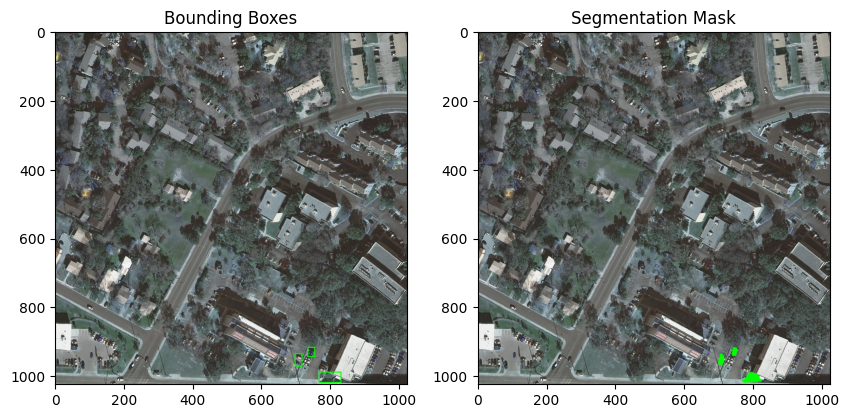

In [ ]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.transforms import functional as F

model = maskrcnn_resnet50_fpn(pretrained=True)
model.eval() 

image_path = "/home/selc-a4-sr2/Solar_Rooftop_Detection/Arial_images_1024_1024/images/3.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  
orig_image = image.copy()

image_tensor = F.to_tensor(image).unsqueeze(0)  

with torch.no_grad():
    output = model(image_tensor)

threshold = 0.5  # Confidence threshold
boxes = output[0]['boxes'].numpy()
masks = output[0]['masks'].squeeze(1).numpy()  # Shape: (N, H, W)
scores = output[0]['scores'].numpy()

# Filter detections based on confidence score
for i in range(len(scores)):
    if scores[i] > threshold:
        # Draw bounding box
        x1, y1, x2, y2 = map(int, boxes[i])
        cv2.rectangle(orig_image, (x1, y1), (x2, y2), (0, 255, 0), 2)

        # Apply mask (binary threshold)
        mask = masks[i] > 0.5
        image[mask] = (0, 255, 0)  # Apply green mask

# Show the result
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(orig_image)
plt.title("Bounding Boxes")

plt.subplot(1, 2, 2)
plt.imshow(image)
plt.title("Segmentation Mask")

plt.show()
